# Processed snapshot

This notebook consolidates the per-spider processing flow into one processed snapshot,
writes the unified JSONL corpus, and persists `manifest.json`.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display


def _find_repo_root() -> Path:
    for candidate in (Path.cwd(), *Path.cwd().resolve().parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise RuntimeError("Repositorio nao encontrado a partir do diretorio atual.")


REPO_ROOT = _find_repo_root()
for path in (REPO_ROOT, REPO_ROOT / "src", REPO_ROOT / "notebooks"):
    path_str = str(path)
    if path_str not in sys.path:
        sys.path.insert(0, path_str)

import eda_utils as eu

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 160)
sns.set_theme(style="whitegrid", palette="crest")

## Selected runs

In [2]:
DATA_DIR = eu.resolve_data_dir(str(REPO_ROOT / "data"))
runs_df = eu.load_runs_df(DATA_DIR)
SPIDERS = [spider for spider in eu.SPIDER_ORDER if spider in set(runs_df["spider"])]
SNAPSHOT_ID = eu.default_snapshot_id()
BATCH_SIZE = 64

selection_map = eu.select_snapshot_runs(DATA_DIR, SPIDERS)
selection_rows = [
    eu.selection_to_frame(selection).iloc[0].to_dict() for selection in selection_map.values()
]
display(pd.DataFrame(selection_rows))

,spider,agency_id,agency_name,selected_run_id,latest_run_id,latest_valid_run_id,fallback_applied,selection_reason,cleaning_flags,diagnostic_run_ids
0,afp_checamos,afp_checamos,AFP Checamos,20260315T010005Z-1d265f16,20260315T010005Z-1d265f16,20260315T010005Z-1d265f16,False,latest_valid_run,"html_unescape, unicode_normalize, collapse_whitespace, light_encoding_fix, drop_generic_editorial_titles",
1,agencia_lupa,agencia_lupa,Agencia Lupa,20260315T160713Z-77601f60,20260315T160713Z-77601f60,20260315T160713Z-77601f60,False,latest_valid_run,"html_unescape, unicode_normalize, collapse_whitespace, light_encoding_fix",
2,aos_fatos,aos_fatos,Aos Fatos,20260315T010005Z-1d265f16,20260315T010005Z-1d265f16,20260315T010005Z-1d265f16,False,latest_valid_run,"html_unescape, unicode_normalize, collapse_whitespace, light_encoding_fix, drop_generic_editorial_titles",
3,boatos_org,boatos_org,Boatos.org,20260315T010005Z-1d265f16,20260315T010005Z-1d265f16,20260315T010005Z-1d265f16,False,latest_valid_run,"html_unescape, unicode_normalize, collapse_whitespace, light_encoding_fix",
4,e_farsas,e_farsas,E-farsas,20260315T010005Z-1d265f16,20260315T010005Z-1d265f16,20260315T010005Z-1d265f16,False,latest_valid_run,"html_unescape, unicode_normalize, collapse_whitespace, light_encoding_fix",
5,estadao_verifica,estadao_verifica,Estadao Verifica,20260315T010005Z-1d265f16,20260315T010005Z-1d265f16,20260315T010005Z-1d265f16,False,latest_valid_run,"html_unescape, unicode_normalize, collapse_whitespace, light_encoding_fix",
6,g1_fato_ou_fake,g1_fato_ou_fake,G1 Fato ou Fake,20260315T010005Z-1d265f16,20260315T010005Z-1d265f16,20260315T010005Z-1d265f16,False,latest_valid_run,"html_unescape, unicode_normalize, collapse_whitespace, light_encoding_fix, direct_fake_fato_mapping",
7,observador,observador,Observador,20260315T143549Z-8506cab9,20260315T143549Z-8506cab9,20260315T143549Z-8506cab9,False,latest_valid_run,"html_unescape, unicode_normalize, collapse_whitespace, light_encoding_fix, ignore_generic_title_in_analysis, claim_summary_priority",
8,poligrafo,poligrafo,Poligrafo,20260315T010005Z-1d265f16,20260315T010005Z-1d265f16,20260315T010005Z-1d265f16,False,latest_valid_run,"html_unescape, unicode_normalize, collapse_whitespace, light_encoding_fix",
9,projeto_comprova,projeto_comprova,Projeto Comprova,20260315T010005Z-1d265f16,20260315T010005Z-1d265f16,20260315T010005Z-1d265f16,False,latest_valid_run,"html_unescape, unicode_normalize, collapse_whitespace, light_encoding_fix, extract_verdict_prefix",


## Export processed snapshot

In [3]:
nlp = eu.load_nlp_model()
manifest = eu.build_snapshot_exports(
    DATA_DIR,
    snapshot_id=SNAPSHOT_ID,
    spiders=SPIDERS,
    nlp=nlp,
    batch_size=BATCH_SIZE,
)

snapshot_dir = DATA_DIR / "processed" / SNAPSHOT_ID
manifest_df = pd.DataFrame(
    [{"spider": spider, **entry} for spider, entry in manifest["spiders"].items()]
).sort_values("spider")
display(manifest_df)

,spider,selected_run_id,latest_run_id,latest_valid_run_id,fallback_applied,selection_reason,exported_records,cleaning_flags,diagnostic_run_ids,agency_id,agency_name
0,afp_checamos,20260315T010005Z-1d265f16,20260315T010005Z-1d265f16,20260315T010005Z-1d265f16,False,latest_valid_run,3981,"[html_unescape, unicode_normalize, collapse_whitespace, light_encoding_fix, drop_generic_editorial_titles]",[],afp_checamos,AFP Checamos
1,agencia_lupa,20260315T160713Z-77601f60,20260315T160713Z-77601f60,20260315T160713Z-77601f60,False,latest_valid_run,1275,"[html_unescape, unicode_normalize, collapse_whitespace, light_encoding_fix]",[],agencia_lupa,Agencia Lupa
2,aos_fatos,20260315T010005Z-1d265f16,20260315T010005Z-1d265f16,20260315T010005Z-1d265f16,False,latest_valid_run,4935,"[html_unescape, unicode_normalize, collapse_whitespace, light_encoding_fix, drop_generic_editorial_titles]",[],aos_fatos,Aos Fatos
3,boatos_org,20260315T010005Z-1d265f16,20260315T010005Z-1d265f16,20260315T010005Z-1d265f16,False,latest_valid_run,12869,"[html_unescape, unicode_normalize, collapse_whitespace, light_encoding_fix]",[],boatos_org,Boatos.org
4,e_farsas,20260315T010005Z-1d265f16,20260315T010005Z-1d265f16,20260315T010005Z-1d265f16,False,latest_valid_run,4361,"[html_unescape, unicode_normalize, collapse_whitespace, light_encoding_fix]",[],e_farsas,E-farsas
5,estadao_verifica,20260315T010005Z-1d265f16,20260315T010005Z-1d265f16,20260315T010005Z-1d265f16,False,latest_valid_run,32,"[html_unescape, unicode_normalize, collapse_whitespace, light_encoding_fix]",[],estadao_verifica,Estadao Verifica
6,g1_fato_ou_fake,20260315T010005Z-1d265f16,20260315T010005Z-1d265f16,20260315T010005Z-1d265f16,False,latest_valid_run,27,"[html_unescape, unicode_normalize, collapse_whitespace, light_encoding_fix, direct_fake_fato_mapping]",[],g1_fato_ou_fake,G1 Fato ou Fake
7,observador,20260315T143549Z-8506cab9,20260315T143549Z-8506cab9,20260315T143549Z-8506cab9,False,latest_valid_run,3910,"[html_unescape, unicode_normalize, collapse_whitespace, light_encoding_fix, ignore_generic_title_in_analysis, claim_summary_priority]",[],observador,Observador
8,poligrafo,20260315T010005Z-1d265f16,20260315T010005Z-1d265f16,20260315T010005Z-1d265f16,False,latest_valid_run,555,"[html_unescape, unicode_normalize, collapse_whitespace, light_encoding_fix]",[],poligrafo,Poligrafo
9,projeto_comprova,20260315T010005Z-1d265f16,20260315T010005Z-1d265f16,20260315T010005Z-1d265f16,False,latest_valid_run,1607,"[html_unescape, unicode_normalize, collapse_whitespace, light_encoding_fix, extract_verdict_prefix]",[],projeto_comprova,Projeto Comprova


## Validate schema and inspect outputs

In [4]:
snapshot_dir = DATA_DIR / "processed" / SNAPSHOT_ID
combined_path = snapshot_dir / "factcheck_scrape_unified.jsonl"
manifest_path = snapshot_dir / "manifest.json"

combined_df = pd.read_json(combined_path, lines=True)
combined_flat = pd.json_normalize(combined_df.to_dict(orient="records"), sep=".")
missing_fields = sorted(set(eu.PROCESSED_RECORD_FIELDS) - set(combined_df.columns))
assert not missing_fields, missing_fields

display(pd.DataFrame([{"combined_path": str(combined_path), "manifest_path": str(manifest_path)}]))
display(combined_df.head(3))
display(combined_flat.head(3))

,combined_path,manifest_path
0,/home/diacrono/Documentos/repositorios/fact-checking-scrape/data/processed/20260316T000305Z-processed/factcheck_scrape_unified.jsonl,/home/diacrono/Documentos/repositorios/fact-checking-scrape/data/processed/20260316T000305Z-processed/manifest.json


,record_id,source_record_id,dataset_id,source_url,published_at,language,title,author,subtitle,claim_text,body_text,analysis_text,text_for_ner,text_without_stopwords,lemmatized_text,original_label,standard_label,category,entities,variant,metadata
0,factcheck_scrape_afp_checamos:c5aac01b1a0a98826c063dbd6eece653edb403fcd0ba1791062bdca09b2b5f27,c5aac01b1a0a98826c063dbd6eece653edb403fcd0ba1791062bdca09b2b5f27,factcheck_scrape_afp_checamos,https://checamos.afp.com/correcoes,NaT,pt-br,Correções,NaN,NaN,Correções,NaN,correções,correções,correções,correção,NaN,missing,NaN,[],claim_summary,"{'analysis_text_length': 9, 'entity_count': 0, 'spider': 'afp_checamos', 'agency_id': 'afp_checamos', 'agency_name': 'AFP Checamos', 'run_id': '20260315T010..."
1,factcheck_scrape_afp_checamos:90129823040861be6113311c238a506816e77370964653e23f557b6b3c04078b,90129823040861be6113311c238a506816e77370964653e23f557b6b3c04078b,factcheck_scrape_afp_checamos,https://checamos.afp.com/doc.afp.com.99X47T3,2026-03-04 16:52:00+00:00,pt-br,Posts usam notícia sobre sumiço de 16 g de urânio para alegar falsamente que Brasil forneceu o material ao Irã,NaN,NaN,Brasil forneceu ao Irã ampolas de urânio que desapareceram em 2023,"Estados Unidos e Israel iniciaram em 28 de fevereiro de 2026 ataques ao Irã após falhas na negociação de um acordo nuclear. Desde então, publicações com mai...",posts usam notícia sobre sumiço de 16 g de urânio para alegar falsamente que brasil forneceu o material ao irã brasil forneceu ao irã ampolas de urânio que ...,posts usam notícia sobre sumiço de 16 g de urânio para alegar falsamente que brasil forneceu o material ao irã brasil forneceu ao irã ampolas de urânio que ...,posts usam notícia sumiço 16 g urânio alegar falsamente brasil forneceu material irã brasil forneceu irã ampolas urânio desapareceram 2023 estados unidos is...,post usar notícia sobre sumiço de 16 g de urânio para alegar falsamente que brasil fornecer o material a o irã brasil fornecer a o irã ampola de urânio que ...,Falso,false,NaN,"[{'text': 'brasil', 'label': 'LOC', 'start_char': 77, 'end_char': 83}, {'text': 'irã brasil', 'label': 'ORG', 'start_char': 107, 'end_char': 117}, {'text': ...",claim_summary,"{'analysis_text_length': 755, 'entity_count': 9, 'spider': 'afp_checamos', 'agency_id': 'afp_checamos', 'agency_name': 'AFP Checamos', 'run_id': '20260315T0..."
2,factcheck_scrape_afp_checamos:fe153abdc496fe65d07b2d91ba593cce9eea5437fd7b07ec73bc4eda1408b27f,fe153abdc496fe65d07b2d91ba593cce9eea5437fd7b07ec73bc4eda1408b27f,factcheck_scrape_afp_checamos,https://checamos.afp.com/,2026-03-15 01:00:06+00:00,pt-br,Checamos,NaN,NaN,Checamos,"O fact-checking da AFP é um departamento da Agence France-Presse (AFP), uma agência de notícias multilíngue e multicultural cuja missão é fornecer uma cober...","checamos o fact-checking da afp é um departamento da agence france-presse (afp), uma agência de notícias multilíngue e multicultural cuja missão é fornecer ...","checamos o fact-checking da afp é um departamento da agence france-presse (afp), uma agência de notícias multilíngue e multicultural cuja missão é fornecer ...",checamos fact-checking afp departamento agence france-presse afp agência notícias multilíngue multicultural missão fornecer cobertura precisa equilibrada im...,checar o fact-checking de o afp ser um departamento de o agence france-presse afp um agência de notícia multilíngue e multicultural cujo missão ser fornecer...,NaN,missing,NaN,"[{'text': 'afp', 'label': 'ORG', 'start_char': 28, 'end_char': 31}, {'text': 'afp', 'label': 'ORG', 'start_char': 75, 'end_char': 78}]",claim_summary,"{'analysis_text_length': 275, 'entity_count': 2, 'spider': 'afp_checamos', 'agency_id': 'afp_checamos', 'agency_name': 'AFP Checamos', 'run_id': '20260315T0..."


,record_id,source_record_id,dataset_id,source_url,published_at,language,title,author,subtitle,claim_text,body_text,analysis_text,text_for_ner,text_without_stopwords,lemmatized_text,original_label,standard_label,category,entities,variant,metadata.analysis_text_length,metadata.entity_count,metadata.spider,metadata.agency_id,metadata.agency_name,metadata.run_id,metadata.latest_run_id,metadata.fallback_applied,metadata.source_type,metadata.source_topics,metadata.source_tags,metadata.source_rating
0,factcheck_scrape_afp_checamos:c5aac01b1a0a98826c063dbd6eece653edb403fcd0ba1791062bdca09b2b5f27,c5aac01b1a0a98826c063dbd6eece653edb403fcd0ba1791062bdca09b2b5f27,factcheck_scrape_afp_checamos,https://checamos.afp.com/correcoes,NaT,pt-br,Correções,NaN,NaN,Correções,NaN,correções,correções,correções,correção,NaN,missing,NaN,[],claim_summary,9,0,afp_checamos,afp_checamos,AFP Checamos,20260315T010005Z-1d265f16,20260315T010005Z-1d265f16,False,ClaimReview,[],[],NaN
1,factcheck_scrape_afp_checamos:90129823040861be6113311c238a506816e77370964653e23f557b6b3c04078b,90129823040861be6113311c238a506816e77370964653e23f557b6b3c04078b,factcheck_scrape_afp_checamos,https://checamos.afp.com/doc.afp.com.99X47T3,2026-03-04 16:52:00+00:00,pt-br,Posts usam notícia sobre sumiço de 16 g de urânio para alegar falsamente que Brasil forneceu o material ao Irã,NaN,NaN,Brasil forneceu ao Irã ampolas de urânio que desapareceram em 2023,"Estados Unidos e Israel iniciaram em 28 de fevereiro de 2026 ataques ao Irã após falhas na negociação de um acordo nuclear. Desde então, publicações com mai...",posts usam notícia sobre sumiço de 16 g de urânio para alegar falsamente que brasil forneceu o material ao irã brasil forneceu ao irã ampolas de urânio que ...,posts usam notícia sobre sumiço de 16 g de urânio para alegar falsamente que brasil forneceu o material ao irã brasil forneceu ao irã ampolas de urânio que ...,posts usam notícia sumiço 16 g urânio alegar falsamente brasil forneceu material irã brasil forneceu irã ampolas urânio desapareceram 2023 estados unidos is...,post usar notícia sobre sumiço de 16 g de urânio para alegar falsamente que brasil fornecer o material a o irã brasil fornecer a o irã ampola de urânio que ...,Falso,false,NaN,"[{'text': 'brasil', 'label': 'LOC', 'start_char': 77, 'end_char': 83}, {'text': 'irã brasil', 'label': 'ORG', 'start_char': 107, 'end_char': 117}, {'text': ...",claim_summary,755,9,afp_checamos,afp_checamos,AFP Checamos,20260315T010005Z-1d265f16,20260315T010005Z-1d265f16,False,ClaimReview,[],[],1
2,factcheck_scrape_afp_checamos:fe153abdc496fe65d07b2d91ba593cce9eea5437fd7b07ec73bc4eda1408b27f,fe153abdc496fe65d07b2d91ba593cce9eea5437fd7b07ec73bc4eda1408b27f,factcheck_scrape_afp_checamos,https://checamos.afp.com/,2026-03-15 01:00:06+00:00,pt-br,Checamos,NaN,NaN,Checamos,"O fact-checking da AFP é um departamento da Agence France-Presse (AFP), uma agência de notícias multilíngue e multicultural cuja missão é fornecer uma cober...","checamos o fact-checking da afp é um departamento da agence france-presse (afp), uma agência de notícias multilíngue e multicultural cuja missão é fornecer ...","checamos o fact-checking da afp é um departamento da agence france-presse (afp), uma agência de notícias multilíngue e multicultural cuja missão é fornecer ...",checamos fact-checking afp departamento agence france-presse afp agência notícias multilíngue multicultural missão fornecer cobertura precisa equilibrada im...,checar o fact-checking de o afp ser um departamento de o agence france-presse afp um agência de notícia multilíngue e multicultural cujo missão ser fornecer...,NaN,missing,NaN,"[{'text': 'afp', 'label': 'ORG', 'start_char': 28, 'end_char': 31}, {'text': 'afp', 'label': 'ORG', 'start_char': 75, 'end_char': 78}]",claim_summary,275,2,afp_checamos,afp_checamos,AFP Checamos,20260315T010005Z-1d265f16,20260315T010005Z-1d265f16,False,NaN,[],[],NaN


## Aggregated comparison across spiders

/tmp/ipykernel_2078149/296853000.py:17: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .assign(month=lambda df: df["published_at_dt"].dt.to_period("M").dt.to_timestamp())


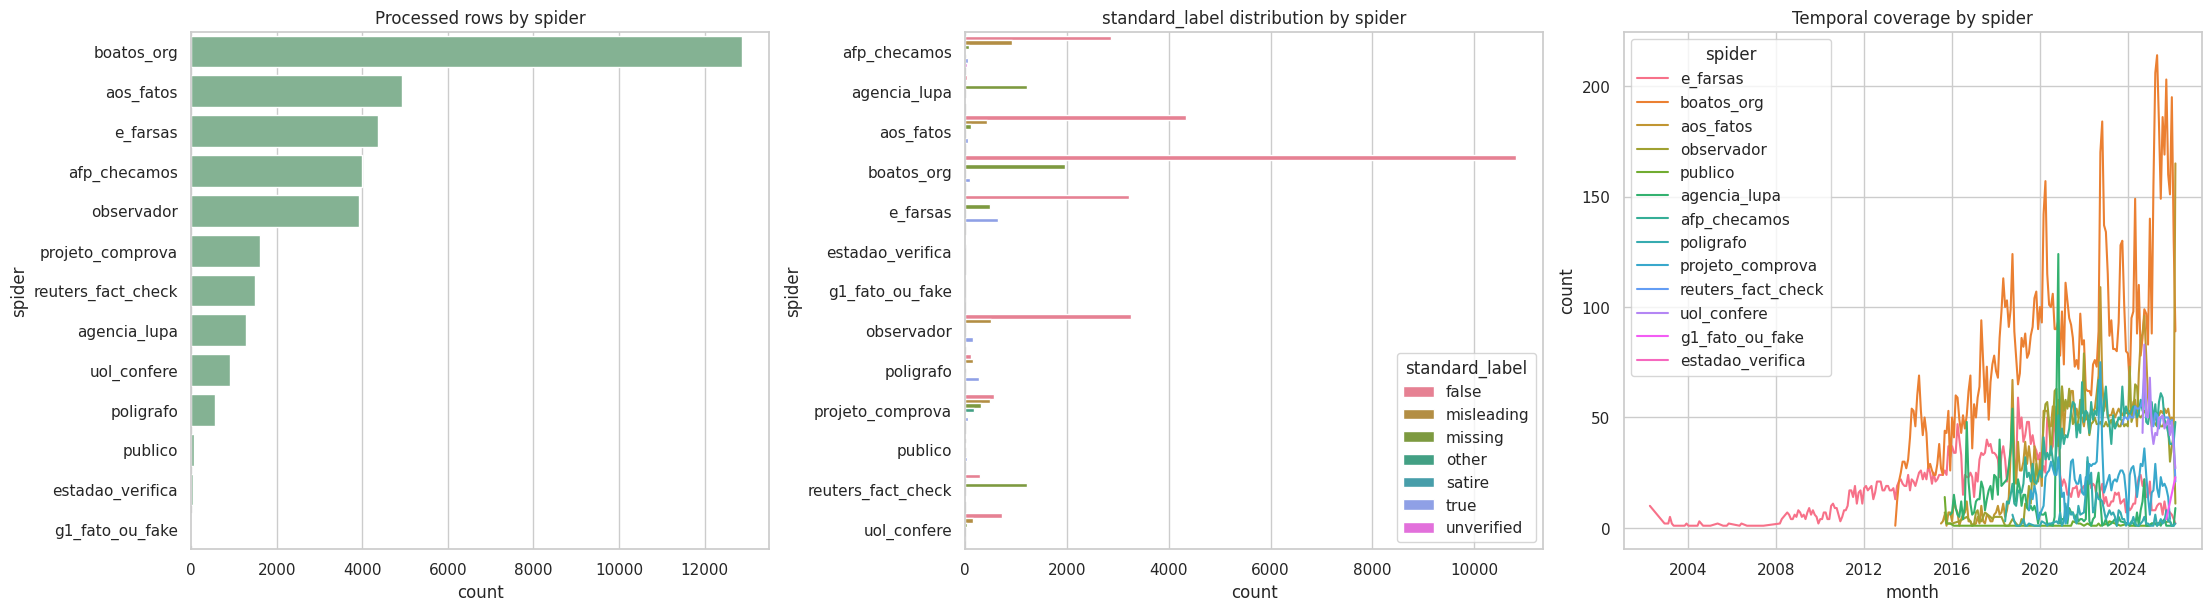

In [5]:
combined_df["published_at_dt"] = pd.to_datetime(
    combined_df["published_at"], utc=True, errors="coerce"
)
volume_by_spider = (
    combined_df["metadata"]
    .apply(lambda meta: meta.get("spider"))
    .value_counts()
    .rename_axis("spider")
    .reset_index(name="count")
)
label_mix = (
    combined_df.assign(spider=combined_df["metadata"].apply(lambda meta: meta.get("spider")))
    .groupby(["spider", "standard_label"])
    .size()
    .reset_index(name="count")
)
timeline = (
    combined_df.assign(spider=combined_df["metadata"].apply(lambda meta: meta.get("spider")))
    .dropna(subset=["published_at_dt"])
    .assign(month=lambda df: df["published_at_dt"].dt.to_period("M").dt.to_timestamp())
    .groupby(["month", "spider"])
    .size()
    .reset_index(name="count")
)

fig, axes = plt.subplots(1, 3, figsize=(22, 6), constrained_layout=True)
sns.barplot(data=volume_by_spider, x="count", y="spider", ax=axes[0])
axes[0].set_title("Processed rows by spider")

sns.barplot(data=label_mix, x="count", y="spider", hue="standard_label", ax=axes[1])
axes[1].set_title("standard_label distribution by spider")

sns.lineplot(data=timeline, x="month", y="count", hue="spider", ax=axes[2])
axes[2].set_title("Temporal coverage by spider")
plt.show()